In [4]:
import tensorflow as tf

In [5]:
first_model = tf.keras.models.load_model('first_model.keras')

C:\Users\matis\OneDrive\Pulpit\Studio_projektowe\GenreAI\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.image import resize
import matplotlib.pyplot as plt

import librosa

data_folder = "../Data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']
def preprocessing_wav_to_melspectogram(data_folder, classes, target_shape = (150,150), chunk_duration = 4, overlap_duration = 2):
    melspectograms_list = []
    labels_list = []
    for class_number, class_name in enumerate(classes):
        class_folder = os.path.join(data_folder, class_name)
        print(f'Processing of class {class_name} data is ongoing')
        for filename in os.listdir(class_folder):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_folder, filename)
                audio_data, sample_rate = librosa.load(file_path, sr = None)
                chunk_samples = int(sample_rate * chunk_duration)
                overlap_samples = int(sample_rate * overlap_duration)

                num_of_chunks = int(np.ceil((len(audio_data) - chunk_samples) /(chunk_samples -  overlap_samples)))+1

                for i in range(num_of_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    chunk = audio_data[start:end]

                    mel_spectogram = librosa.feature.melspectrogram(y = chunk, sr = sample_rate)

                    mel_spectogram = resize(np.expand_dims(mel_spectogram, axis = -1),target_shape)

                    melspectograms_list.append(mel_spectogram)
                    labels_list.append(class_number)
    return np.array(melspectograms_list), np.array(labels_list)
data, labels = preprocessing_wav_to_melspectogram(data_folder, classes)

Processing of class blues data is ongoing
Processing of class classical data is ongoing
Processing of class country data is ongoing
Processing of class disco data is ongoing
Processing of class hiphop data is ongoing
Processing of class jazz data is ongoing
Processing of class metal data is ongoing
Processing of class pop data is ongoing
Processing of class reggae data is ongoing
Processing of class rock data is ongoing


In [8]:
D

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step


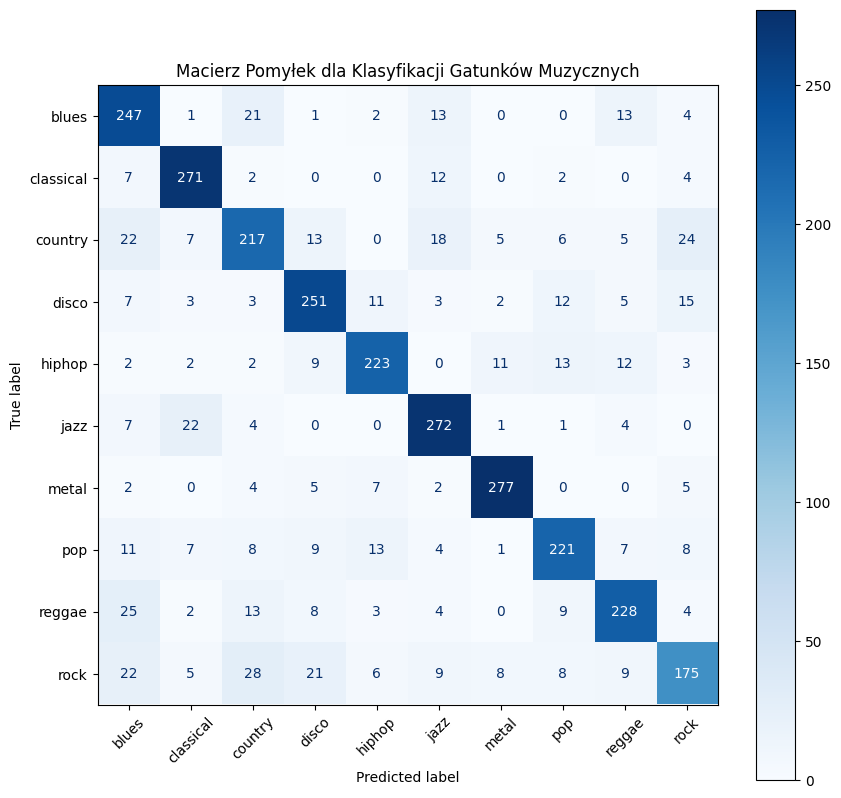

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
Y_pred_proba = first_model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10)) # Ustaw większy rozmiar
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Macierz Pomyłek dla Klasyfikacji Gatunków Muzycznych')
plt.xticks(rotation=45) # Obróć etykiety X, aby były czytelne
plt.show()